In [23]:
# Procesamiento de Señales Biológicas
## Exploración Inicial de Señales EMG

# Integrantes
# Bastián Caris  
# Martín Castillo  
# Camila San Martín  
# Asignatura: Electivo 1: Procesamiento de señales biológicas
# Descripción:
#   Análisis preliminar de señales EMG superficiales reales, incluyendo:
#   visualización temporal, métricas básicas y análisis frecuencial (FFT).
#
# Fuente de datos:
#   Archivos CSV con registros de 11 sujetos.
#   Columnas: sujeto, Time_s, RF, BF, VM, ST, FX
#   RF = Rectus Femoris 
#   BF = Biceps Femoris
#   VM = Vastus Medialis 
#   ST = Semitendinosus
#   FX = Fuerza externa [N]

In [1]:
# Se importan las librerías utilizadas
import os
import pandas as pd                        # Para manejo de datos 
import numpy as np                         # Análisis numérico
import matplotlib.pyplot as plt            # Visualización
from scipy.fft import fft, fftfreq         # Para trabajar Fast Fourier Transform
os.makedirs("Figures", exist_ok=True)      # Crear carpeta para guardar figuras


In [2]:
# 1. Cargar una señal desde archivo o generar una señal sintética justificada.

datos = pd.read_csv(r"C:\Users\tito_\EMG-Signal-Processing\Data\datos.csv") # Cargar datos desde CSV

# Sujeto y canal a analizar (modificar según necesidad)
SUJETO = "1Nmar"
CANAL  = "RF"      # Se decide trabajar con Rectus Femoris (RF), pero esto se puede editar depediendo el interés (BF, VM, ST).

# Filtrar por sujeto seleccionado
df = datos[datos["sujeto"] == SUJETO].reset_index(drop=True)
df = df.dropna(subset=[CANAL]).reset_index(drop=True)
print(f"Filas después de limpiar: {len(df)}")

print(f"Sujetos disponibles : {list(datos['sujeto'].unique())}")
print(f"Canales EMG         : RF, BF, VM, ST")
print(f"\nSujeto: {SUJETO} | Canal: {CANAL}")
print(f"Filas cargadas      : {len(df)}")


Filas después de limpiar: 5681
Sujetos disponibles : ['1Nmar', '2Nmar', '3Nmar', '4Nmar', '5Nmar', '6Nmar', '7Nmar', '8Nmar', '9Nmar', '10Nmar', '11Nmar']
Canales EMG         : RF, BF, VM, ST

Sujeto: 1Nmar | Canal: RF
Filas cargadas      : 5681


In [3]:
# 2. Definir la frecuencia de muestreo fs, el período de muestreo Ts, el número de muestras N y el vector temporal.

t   = df["Time_s"].values   # Vector temporal [s], se toma como la fila "Time_s" del CSV.
emg = df[CANAL].values      # Señal EMG del canal seleccionado [mV], se toma como la fila del canal seleccionado (RF) del CSV.


Ts         = round(t[1] - t[0], 6)   # Período de muestreo [s]
#Ts es un milisegundo.

frecuencia = int(round(1 / Ts))      # Frecuencia de muestreo [Hz]
N          = len(t)                  # Número de muestras
duracion   = t[-1] - t[0]            # Duración total [s]
Periodomuestreo = Ts*1000            # Período de muestreo [ms]



print("Parámetros de muestreo:")
print("\n")
print(f"Frecuencia de muestreo (fs) : {frecuencia} Hz")
print(f"Período de muestreo   (Ts)  : {Periodomuestreo:.4f} ms")
print(f"Número de muestras    (N)   : {N}")
print(f"Duración total              : {duracion:.4f} s")


Parámetros de muestreo:


Frecuencia de muestreo (fs) : 1000 Hz
Período de muestreo   (Ts)  : 1.0000 ms
Número de muestras    (N)   : 5681
Duración total              : 5.6800 s


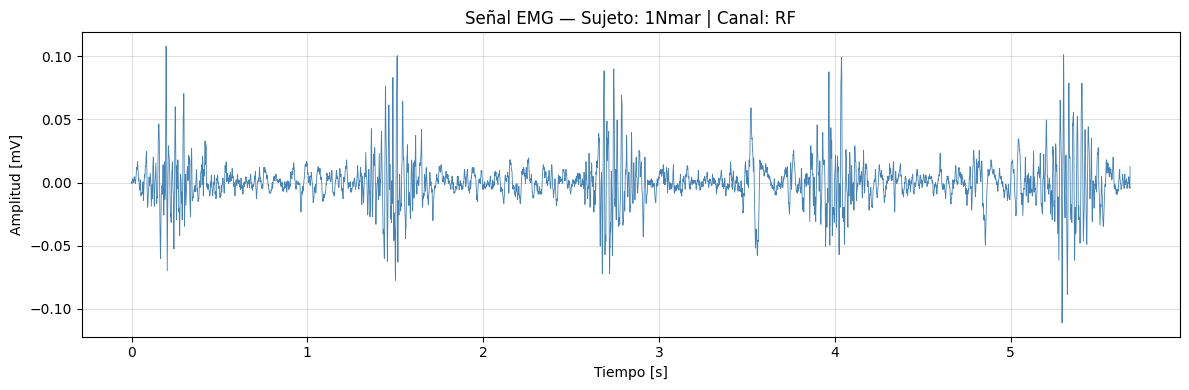

In [4]:
# 3. Graficar la señal en el dominio del tiempo con unidades correctas.

plt.figure(figsize=(12, 4))
plt.plot(t, emg, linewidth=0.6, color='steelblue')
plt.title(f"Señal EMG — Sujeto: {SUJETO} | Canal: {CANAL}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.grid(True, alpha=0.4)
plt.tight_layout()
os.makedirs("figures", exist_ok=True) # Por comodidad se crea la carpeta "figures" para guardar las figuras generadas.
plt.savefig("figures/emg_RF_1Nmar_temporal.png", dpi=300)
plt.show()

In [5]:
# 4. Calcular duración total, amplitud máxima, amplitud mínima, media, desviación estándar, energía y potencia promedio.



duracion_total = N * Ts         # La duración total se calcula multiplicando el número de muestras (N) por el período de muestreo (Ts), lo que da la duración total de la señal en segundos.
amplitud_max   = np.max(emg)    # La amplitud máxima se calcula utilizando la función np.max, que devuelve el valor máximo de las muestras de la señal EMG.
amplitud_min   = np.min(emg)    # La amplitud mínima se calcula utilizando la función np.min, que devuelve el valor mínimo de las muestras de la señal EMG.
media          = np.mean(emg)   # La media se calcula utilizando la función np.mean, que devuelve el valor promedio de las muestras de la señal EMG.
std            = np.std(emg)    # La desviación estándar se calcula utilizando la función np.std, que mide la dispersión de los valores de la señal EMG alrededor de su media.
energia        = np.sum(emg**2) # La energía se calcula como la suma de los cuadrados de las muestras, lo que es común en señales discretas.
potencia       = energia / N    # La potencia promedio se calcula dividiendo la energía total por el número de muestras, lo que da una medida de la potencia media de la señal.

print(f"Duración total      : {duracion_total:.4f} [s]")
print(f"Amplitud máxima     : {amplitud_max:.4f} [mV]")
print(f"Amplitud mínima     : {amplitud_min:.4f} [mV]")

# Se utiliza una convención de 4 decimales debido a que las señales EMG suelen tener valores pequeños, y esto permite una mejor visualización.


print(f"Media               : {media:.8f} [mV]")
print(f"Desviación estándar : {std:.8f} [mV]")
print(f"Energía             : {energia:.8f} [mV²]")
print(f"Potencia promedio   : {potencia:.8f} [mV²]")

Duración total      : 5.6810 [s]
Amplitud máxima     : 0.1080 [mV]
Amplitud mínima     : -0.1110 [mV]
Media               : 0.00042401 [mV]
Desviación estándar : 0.01679494 [mV]
Energía             : 1.60346174 [mV²]
Potencia promedio   : 0.00028225 [mV²]


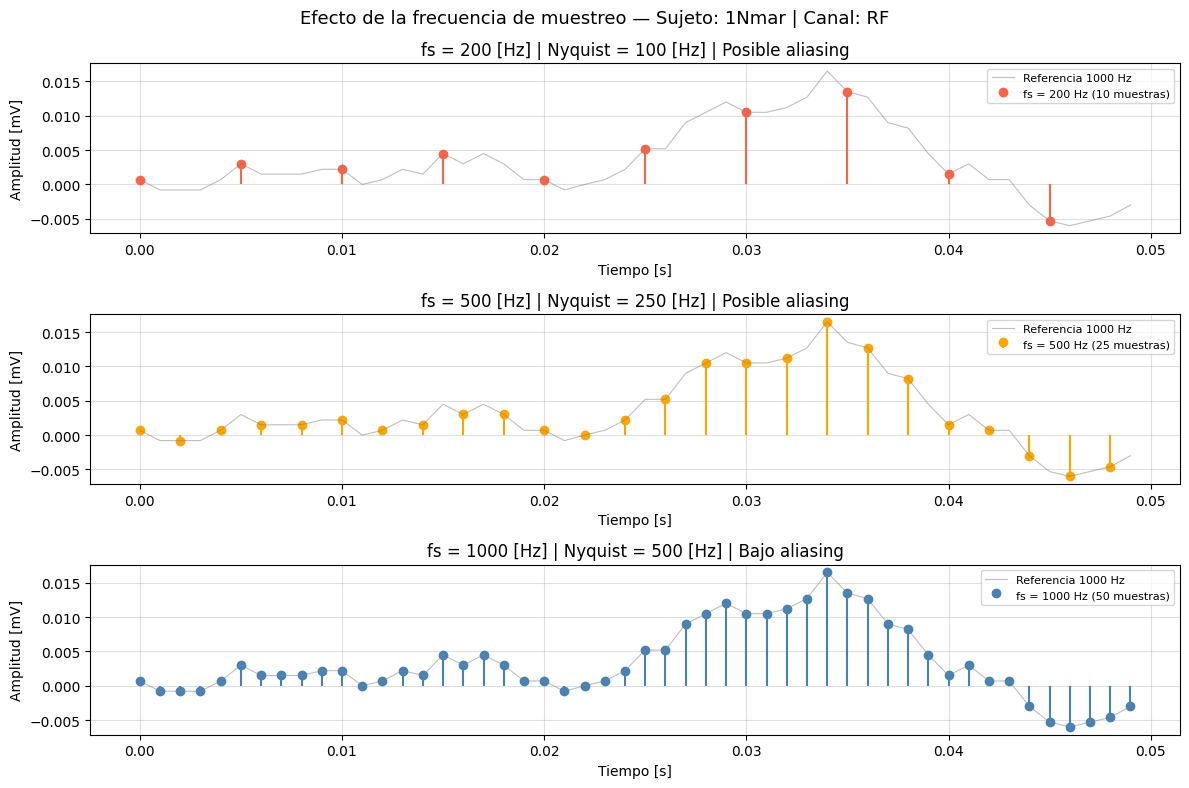

Frecuencia de muestreo original : 1000 [Hz]
Frecuencia de Nyquist           : 500 [Hz]


In [6]:
# 5. Mostrar un ejemplo de discretización temporal y discutir el efecto de modificar fs.

# Se toma una ventana corta de 50 ms para visualizar mejor el efecto del muestreo
n_ventana = int(0.05 * frecuencia)  # 50 ms × 1000 Hz = 50 muestras
t_ref     = t[:n_ventana]           # Vector temporal de referencia
emg_ref   = emg[:n_ventana]         # Señal EMG de referencia

# Se comparan tres frecuencias de muestreo para ilustrar el teorema de Nyquist
fs_lista = [200, 500, 1000]         # Frecuencias a comparar [Hz]
colores  = ['tomato', 'orange', 'steelblue']

fig, axes = plt.subplots(len(fs_lista), 1, figsize=(12, 8))  # sin sharex

for ax, fs_i, color in zip(axes, fs_lista, colores):
    # Submuestreo: se toma 1 de cada k muestras para simular una fs menor
    k     = frecuencia // fs_i  # Factor de submuestreo
    t_i   = t_ref[::k]          # Tiempos submuestreados
    emg_i = emg_ref[::k]        # Muestras submuestreadas

    ax.stem(t_i, emg_i, linefmt=color, markerfmt='o', basefmt=' ',
            label=f"fs = {fs_i} Hz ({len(t_i)} muestras)")
    ax.plot(t_ref, emg_ref, color='gray', linewidth=0.8, alpha=0.5,
            label=f'Referencia {frecuencia} Hz')
    ax.set_xlabel("Tiempo [s]")     # eje x en cada subplot
    ax.set_ylabel("Amplitud [mV]")
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.4)

    # Nyquist: la fs debe ser al menos el doble de la frecuencia máxima de la señal
    f_max_emg  = frecuencia // 2
    alias_warn = "Posible aliasing" if fs_i // 2 < f_max_emg else "Bajo aliasing"
    ax.set_title(f"fs = {fs_i} [Hz] | Nyquist = {fs_i//2} [Hz] | {alias_warn}")

fig.suptitle(
    f"Efecto de la frecuencia de muestreo — Sujeto: {SUJETO} | Canal: {CANAL}",
    fontsize=13
)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/emg_discretizacion.png", dpi=300)
plt.show()


print(f"Frecuencia de muestreo original : {frecuencia} [Hz]")
print(f"Frecuencia de Nyquist           : {frecuencia//2} [Hz]")

In [24]:
# 6. Calcular la resolución de cuantización para un número de bits definido.


# La resolución indica el menor cambio de voltaje que el sistema puede detectar.
# Fórmula: Δ = (Vmax - Vmin) / 2^B


bits_lista = [4, 8, 12, 16]  # Número de bits a comparar

Vmax = amplitud_max  # Valor máximo de la señal [mV]
Vmin = amplitud_min  # Valor mínimo de la señal [mV]

# Se resuelve la cuantización

print(f"  Vmax = {Vmax:.6f} [mV]  |  Vmin = {Vmin:.6f} [mV]")
print(f"  {'Bits':>5}  {'Niveles':>10}  {'Δ [mV]':>16}")


for B in bits_lista:
    niveles = 2**B
    delta   = (Vmax - Vmin) / niveles  # Resolución por nivel
    print(f"  {B:>5}  {niveles:>10}  {delta:>16.8f}")

# Se elige 12 bits como referencia, típico en sistemas de adquisición EMG
B_default     = 12
delta_default = (Vmax - Vmin) / (2**B_default)


print(f"\n  → Se selecciona B = {B_default} bits como referencia.")
print(f"    Δ       = {delta_default:.8f} [mV]")

  Vmax = 0.108000 [mV]  |  Vmin = -0.111000 [mV]
   Bits     Niveles            Δ [mV]
      4          16        0.01368750
      8         256        0.00085547
     12        4096        0.00005347
     16       65536        0.00000334

  → Se selecciona B = 12 bits como referencia.
    Δ       = 0.00005347 [mV]


In [ ]:
# 7. Estimar o discutir el error máximo de cuantización.
# Dado por |eq|max = Δ/2


# Representa el peor caso posible de error al discretizar la señal.

eq_max_default = delta_default / 2  # Error máximo de cuantización [mV]

print(f"  Para B = {B_default} bits:")
print(f"  Δ       = {delta_default:.8f} [mV]")
print(f"  |eq|max = {eq_max_default:.8f} [mV]")
rango = Vmax - Vmin
print(f"  Representa el {100*eq_max_default/rango:.6f}% del rango total de la señal.")

  Para B = 12 bits:
  Δ       = 0.00005347 [mV]
  |eq|max = 0.00002673 [mV]
  Representa el 0.012207% del rango total de la señal.


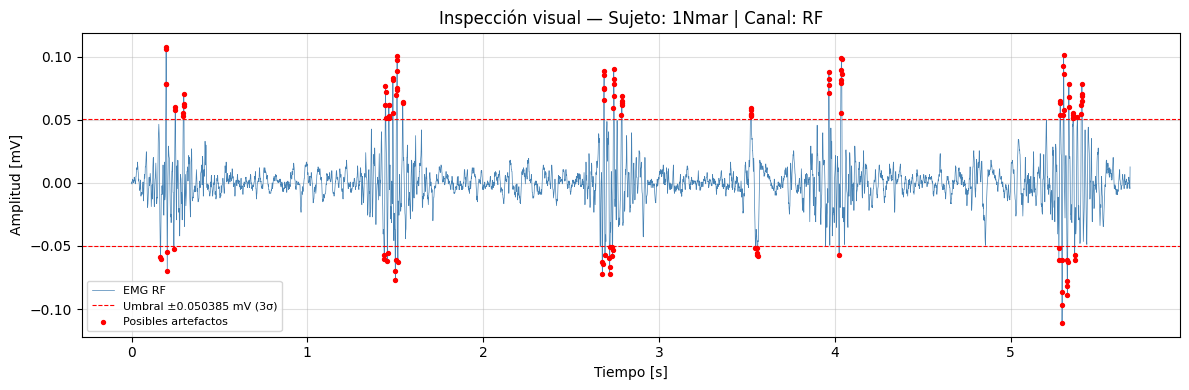

  Umbral (3σ)               : ±0.050385 mV
  Muestras fuera del umbral : 126 (2.22% del total)
  Se detectaron posibles artefactos.


In [54]:
# 8. Inspeccionar visualmente la calidad de la señal e identificar posibles artefactos

# Se usa un umbral estadístico de 3σ para detectar muestras sospechosas.

umbral = 3 * std  # Umbral heurístico: 3 desviaciones estándar

# Índices donde la señal supera el umbral
idx_outliers = np.where(np.abs(emg) > umbral)[0] # np.where devuelve los índices donde la condición se cumple, en este caso donde el valor absoluto de la señal EMG supera el umbral definido.

fig, ax = plt.subplots(figsize=(12, 4)) 

ax.plot(t, emg, color='steelblue', lw=0.5, label=f'EMG {CANAL}')
ax.axhline(y= umbral, color='red', linestyle='--', lw=0.8,
           label=f'Umbral ±{umbral:.6f} mV (3σ)')
ax.axhline(y=-umbral, color='red', linestyle='--', lw=0.8)
if len(idx_outliers) > 0:
    ax.scatter(t[idx_outliers], emg[idx_outliers],
               color='red', s=8, zorder=5, label='Posibles artefactos')
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("Amplitud [mV]")
ax.set_title(f"Inspección visual — Sujeto: {SUJETO} | Canal: {CANAL}")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/emg_artefactos.png", dpi=300)
plt.show()

print(f"  Umbral (3σ)               : ±{umbral:.6f} mV")
print(f"  Muestras fuera del umbral : {len(idx_outliers)} ({100*len(idx_outliers)/N:.2f}% del total)")
if len(idx_outliers) == 0:
    print("  No se detectaron artefactos evidentes con el criterio 3σ.")
else:
    print("  Se detectaron posibles artefactos.")

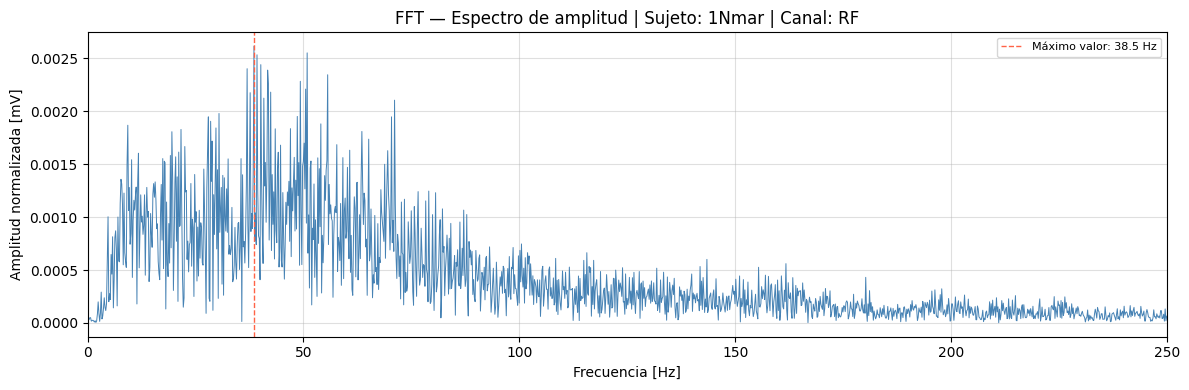

  Frecuencia máxima: 38.5 Hz
  El espectro EMG se concentra principalmente entre 20 y 170 Hz.


In [68]:
# 9. Visualización preliminar en frecuencia mediante FFT.

yf  = fft(emg)        # Transformada de Fourier de la señal EMG
xf  = fftfreq(N, Ts)  # Vector de frecuencias correspondiente

# Solo frecuencias positivas (la segunda mitad es simétrica y no aporta información)
xf_pos = xf[:N//2]
yf_pos = np.abs(yf[:N//2]) * 2 / N  # Amplitud normalizada [mV]

# Frecuencia dominante 
indice_maximo    = np.argmax(yf_pos)  
f_maxima = xf_pos[indice_maximo ]

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(xf_pos, yf_pos, color='steelblue', lw=0.7)
ax.axvline(x=f_maxima, color='tomato', linestyle='--', lw=1,
           label=f'Máximo valor: {f_maxima:.1f} Hz')
ax.set_title(f"FFT — Espectro de amplitud | Sujeto: {SUJETO} | Canal: {CANAL}")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Amplitud normalizada [mV]")
ax.set_xlim(0, 250)  # Rango cercano al típico de EMG superficial
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/emg_fft.png", dpi=300)
plt.show()

print(f"  Frecuencia máxima: {f_maxima:.1f} Hz")
print("  El espectro EMG se concentra principalmente entre 20 y 170 Hz.")
